# Notebook 02: Preprocessing Test

**Goal:** Verify that Stage 1 loaders and Stage 2 preprocessing work correctly.

**Covers:**
- Loading all four data sources via project loaders
- Text cleaning on clinical notes
- Lab value normalization
- Vitals temporal alignment
- Cohort construction and label assignment

In [6]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from configs.paths import PATHS
from configs.pipeline_config import PIPELINE_CFG

sns.set_theme(style='whitegrid')
print('Preprocessing Test Notebook')
print('Project root:', PATHS.project_root)

Preprocessing Test Notebook
Project root: C:\Users\Dell\OneDrive - AL-Hussien bin Abdullah Technical University\ClinNote\Cpastone 2\ClinNote code\ClinNote


## 2.1 Stage 1 — Load All Data Sources

In [7]:
from src.stage1_data_loading.patient_loader import PatientLoader
from src.stage1_data_loading.notes_loader import NotesLoader
from src.stage1_data_loading.labs_loader import LabsLoader
from src.stage1_data_loading.vitals_loader import VitalsLoader

patient_loader = PatientLoader()
notes_loader   = NotesLoader()
labs_loader    = LabsLoader()
vitals_loader  = VitalsLoader()

patients_df = patient_loader.load()
notes_df    = notes_loader.load()
labs_df     = labs_loader.load()
vitals_df   = vitals_loader.load()

print(f"Patients : {len(patients_df):>6} rows, {patients_df['subject_id'].nunique()} subjects")
print(f"Notes    : {len(notes_df):>6} rows")
print(f"Labs     : {len(labs_df):>6} rows")
print(f"Vitals   : {len(vitals_df):>6} rows")


[PatientLoader] Shape: (546028, 22)
  hospital_expire_flag=0 (survived): 534,227  (97.8%)
  hospital_expire_flag=1 (died):     11,801  (2.2%)
  Null counts:
    deathtime: 534,238
    admit_provider_id: 4
    admission_location: 1
    discharge_location: 149,818
    insurance: 9,355
    language: 775
    marital_status: 13,619
    edregtime: 166,788
    edouttime: 166,788
    dod: 401,062

[NotesLoader] Shape: (363, 8)
  note_type distribution:
    RR: 361
    AR: 2
  Average text length: 1,118 characters

[LabsLoader] Shape: (158574, 15)
  Unique itemids: 189
  Unique labels:  181
  Flag distribution:
    (normal/null): 109,570
    abnormal: 49,004

[VitalsLoader] Shape: (114547, 13)
  vital_source distribution:
    chartevents: 112,705
    procedureevents: 835
    inputevents: 600
    omr: 407
  Top 15 most frequent labels:
    Pain Assessment Method: 2,000
    Patient Weight: 1,435
    Admission Weight (Kg): 1,000
    Manual Blood Pressure Systolic Left: 1,000
    Unable to assess 

## 2.2 Stage 2 — Preprocessing

In [8]:
from src.stage2_preprocessing.text_cleaner import TextCleaner
from src.stage2_preprocessing.labs_preprocessor import LabsPreprocessor
from src.stage2_preprocessing.vitals_preprocessor import VitalsPreprocessor
from src.stage2_preprocessing.patient_matcher import PatientMatcher
from src.stage1_data_loading.cohort_builder import CohortBuilder

print("Preprocessors imported successfully.")

Preprocessors imported successfully.


### 2.2a Text Preprocessing

In [9]:
text_cleaner = TextCleaner()
notes_clean = text_cleaner.clean_dataframe(notes_df, text_col='text')

print(f"Notes before: {len(notes_df):>6} rows")
print(f"Notes after : {len(notes_clean):>6} rows")
print("\nColumns:", notes_clean.columns.tolist())
notes_clean.head(3)


[TextCleaner] Rows before cleaning: 363
[TextCleaner] Rows after cleaning:  363
[TextCleaner] Dropped (empty after clean): 0
[TextCleaner] Avg text length after: 1,089 characters
Notes before:    363 rows
Notes after :    363 rows

Columns: ['subject_id', 'hadm_id', 'note_id', 'note_type', 'note_seq', 'charttime', 'storetime', 'text', 'text_cleaned']


,subject_id,hadm_id,note_id,note_type,note_seq,charttime,storetime,text,text_cleaned
0,10000032,22595853.0,10000032-RR-14,RR,14,2180-05-06 21:19:00,2180-05-06 23:32:00,EXAMINATION: CHEST (PA AND LAT) INDICATION: [R...,EXAMINATION: CHEST (PA AND LAT) INDICATION: [R...
1,10000032,22595853.0,10000032-RR-15,RR,15,2180-05-06 23:00:00,2180-05-06 23:26:00,EXAMINATION: LIVER OR GALLBLADDER US (SINGLE O...,EXAMINATION: LIVER OR GALLBLADDER US (SINGLE O...
2,10000032,22595853.0,10000032-RR-16,RR,16,2180-05-07 09:55:00,2180-05-07 11:15:00,INDICATION: [REDACTED] HCV cirrhosis c/b ascit...,INDICATION: [REDACTED] HCV cirrhosis c/b ascit...


In [10]:
# Sample cleaned text
text_col = 'text_cleaned' if 'text_cleaned' in notes_clean.columns else 'text'
print("Sample cleaned note (first 500 chars):")
print(str(notes_clean[text_col].iloc[0])[:500])

Sample cleaned note (first 500 chars):
EXAMINATION: CHEST (PA AND LAT) INDICATION: [REDACTED] with new onset ascites // eval for infection TECHNIQUE: Chest PA and lateral COMPARISON: None. FINDINGS: There is no focal consolidation, pleural effusion or pneumothorax. Bilateral nodular opacities that most likely represent nipple shadows. The cardiomediastinal silhouette is normal. Clips project over the left lung, potentially within the breast. The imaged upper abdomen is unremarkable. Chronic deformity of the posterior left sixth and s


### 2.2b Lab Preprocessing

In [11]:
labs_preprocessor = LabsPreprocessor()
labs_clean = labs_preprocessor.preprocess(labs_df)

print(f"Labs before: {len(labs_df):>6} rows")
print(f"Labs after : {len(labs_clean):>6} rows")
print("\nColumns:", labs_clean.columns.tolist())
labs_clean.head(3)


[LabsPreprocessor] Rows before: 158,574
[LabsPreprocessor] Rows after:  8,291
[LabsPreprocessor] Dropped: 150,283
  Unique labels: 181
  Abnormal rate: 33.0%
  Avg severity score: 0.5996
Labs before: 158574 rows
Labs after :   8291 rows

Columns: ['subject_id', 'hadm_id', 'itemid', 'label', 'charttime', 'storetime', 'value', 'valuenum', 'valueuom', 'ref_range_lower', 'ref_range_upper', 'flag', 'is_missing', 'is_outlier', 'is_abnormal', 'severity_score']


,subject_id,hadm_id,itemid,label,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,is_missing,is_outlier,is_abnormal,severity_score
0,10000117,NaN,51087,Length of Urine Collection,2174-10-22 18:22:00,NaT,24,24.0,NaN,NaN,NaN,NaN,False,False,False,0.0
1,10000117,NaN,51108,Urine Volume,2174-10-22 18:22:00,NaT,2225,2225.0,mL,NaN,NaN,NaN,False,False,False,0.0
2,10000826,28289260.0,51087,Length of Urine Collection,2147-01-02 10:47:00,NaT,24,24.0,NaN,NaN,NaN,NaN,False,False,False,0.0


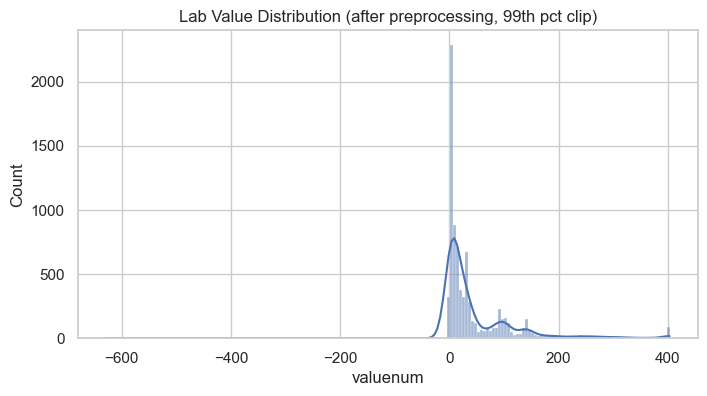

In [12]:
val_col = 'valuenum' if 'valuenum' in labs_clean.columns else 'value'
numeric_vals = pd.to_numeric(labs_clean[val_col], errors='coerce').dropna()

plt.figure(figsize=(8, 4))
sns.histplot(numeric_vals.clip(upper=numeric_vals.quantile(0.99)), kde=True)
plt.title('Lab Value Distribution (after preprocessing, 99th pct clip)')
plt.xlabel(val_col)
plt.show()

### 2.2c Vitals Preprocessing

In [13]:
vitals_preprocessor = VitalsPreprocessor()
vitals_clean = vitals_preprocessor.preprocess(vitals_df)

print(f"Vitals before: {len(vitals_df):>6} rows")
print(f"Vitals after : {len(vitals_clean):>6} rows")
print("\nColumns:", vitals_clean.columns.tolist())
vitals_clean.head(3)


[VitalsPreprocessor] Rows before: 114,547
[VitalsPreprocessor] Rows after:  75,236
[VitalsPreprocessor] Dropped: 39,311
  Top 15 label distribution:
    Temperature Celsius: 1,984
    Patient Weight: 1,435
    Admission Weight (Kg): 1,000
    O2 Saturation Pulseoxymetry Alarm - Low: 1,000
    PAR-Oxygen saturation: 1,000
    Feeding Weight: 1,000
    Unintentional weight loss >10 lbs.: 1,000
    Tidal Volume (spontaneous): 1,000
    Tidal Volume (observed): 1,000
    Unable to assess pain: 1,000
    Currently experiencing pain: 1,000
    SpO2 Desat Limit: 1,000
    Respiratory Rate: 1,000
    Respiratory Rate (spontaneous): 1,000
    Admission Weight (lbs.): 1,000
  Abnormal rate: 16.1%
Vitals before: 114547 rows
Vitals after :  75236 rows

Columns: ['subject_id', 'hadm_id', 'label', 'charttime', 'value', 'stay_id', 'is_abnormal']


,subject_id,hadm_id,label,charttime,value,stay_id,is_abnormal
0,10000032,29079034.0,Admission Weight (Kg),2180-07-23 12:36:00,39.4,39553978.0,False
1,10000032,29079034.0,Admission Weight (lbs.),2180-07-23 14:22:00,86.7,39553978.0,False
2,10000032,29079034.0,Admission Weight (lbs.),2180-07-23 14:44:00,86.7,39553978.0,False


### 2.2d Cohort Building

In [14]:
cohort_builder = CohortBuilder()
cohort = cohort_builder.build(patients_df, notes_clean, labs_clean, vitals_clean)

print(f"Cohort size: {len(cohort)} admissions")
print("\nCohort columns:", cohort.columns.tolist())
cohort.head()


[CohortBuilder] Patients with notes:  42
[CohortBuilder] Patients with labs:   27
[CohortBuilder] Patients with vitals: 5,319
[CohortBuilder] Patients in ALL 4 sources: 2

[CohortBuilder] Final cohort size: 11 admissions
  hospital_expire_flag=0 (survived): 11  (100.0%)
  hospital_expire_flag=1 (died):     0  (0.0%)
  Class balance: 0.0% positive (mortality)
[CohortBuilder] Cohort saved -> C:\Users\Dell\OneDrive - AL-Hussien bin Abdullah Technical University\ClinNote\Cpastone 2\ClinNote code\ClinNote\outputs\features\cohort.pkl
Cohort size: 11 admissions

Cohort columns: ['subject_id', 'hadm_id', 'hospital_expire_flag', 'gender', 'anchor_age', 'los_days']


,subject_id,hadm_id,hospital_expire_flag,gender,anchor_age,los_days
0,10000032,22595853,0,F,52,0.786111
1,10000032,22841357,0,F,52,1.015278
2,10000032,25742920,0,F,52,1.754167
3,10000032,29079034,0,F,52,2.222222
4,10000980,20897796,0,F,73,2.587500


Cohort mortality rate: 0.000


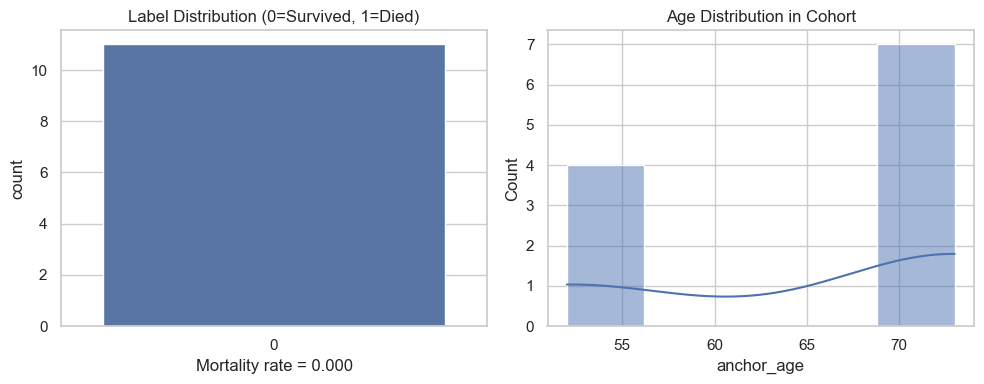

In [15]:
if 'hospital_expire_flag' in cohort.columns:
    mort_rate = cohort['hospital_expire_flag'].mean()
    print(f"Cohort mortality rate: {mort_rate:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.countplot(x='hospital_expire_flag', data=cohort, ax=axes[0])
    axes[0].set_title('Label Distribution (0=Survived, 1=Died)')
    axes[0].set_xlabel(f'Mortality rate = {mort_rate:.3f}')

    if 'anchor_age' in cohort.columns:
        sns.histplot(cohort['anchor_age'], kde=True, ax=axes[1])
        axes[1].set_title('Age Distribution in Cohort')

    plt.tight_layout()
    plt.show()

## 2.3 Save Preprocessed Outputs

In [16]:
PATHS.ensure_output_dirs()

processed_dir = PATHS.output_root / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

cohort_path = processed_dir / 'cohort.csv'
cohort.to_csv(cohort_path, index=False)
print(f"Cohort saved -> {cohort_path}")

notes_path = processed_dir / 'notes_clean.csv'
notes_clean.to_csv(notes_path, index=False)
print(f"Clean notes -> {notes_path}")

labs_path = processed_dir / 'labs_clean.csv'
labs_clean.to_csv(labs_path, index=False)
print(f"Clean labs  -> {labs_path}")

vitals_path = processed_dir / 'vitals_clean.csv'
vitals_clean.to_csv(vitals_path, index=False)
print(f"Clean vitals-> {vitals_path}")

Cohort saved -> C:\Users\Dell\OneDrive - AL-Hussien bin Abdullah Technical University\ClinNote\Cpastone 2\ClinNote code\ClinNote\outputs\processed\cohort.csv
Clean notes -> C:\Users\Dell\OneDrive - AL-Hussien bin Abdullah Technical University\ClinNote\Cpastone 2\ClinNote code\ClinNote\outputs\processed\notes_clean.csv
Clean labs  -> C:\Users\Dell\OneDrive - AL-Hussien bin Abdullah Technical University\ClinNote\Cpastone 2\ClinNote code\ClinNote\outputs\processed\labs_clean.csv
Clean vitals-> C:\Users\Dell\OneDrive - AL-Hussien bin Abdullah Technical University\ClinNote\Cpastone 2\ClinNote code\ClinNote\outputs\processed\vitals_clean.csv
